# Notebook De Jean-Baptiste CHEZE

### Ce qu'il faut savoir sur le DataSet : 
- Les données viennent du site EaseMyTrip (données secondaires).
- Elles ont été récoltées via Octoparse, un outil de web scraping.
- Période de collecte : 50 jours, du 11 février au 31 mars 2022.

Données séparées selon la classe du billet :
- Économie
- Business

Nombre total d’observations : 300 261 options de vol.

### Problématique / Questions de recherche

1. Le prix varie-t-il selon la compagnie aérienne ?
- Utiliser un test ANOVA pour comparer les prix entre compagnies.

2. Acheter 1 ou 2 jours avant le départ augmente-t-il le prix ?
- Étudier la relation entre days_left et le prix (analyse statistique ou graphique).

3. Le prix dépend-il de l’heure de départ et de l’heure d’arrivée ?
- Catégoriser les heures (matin, après-midi, nuit…) puis comparer les prix via tests ou modèle linéaire.

4. Le prix change-t-il selon la ville de départ et la ville d’arrivée ?
- Comparer les prix selon les routes (ex. Delhi–Mumbai, Chennai–Bangalore…).

5. Le prix est-il plus élevé en business qu’en economy, et de combien ?
- Comparer les deux classes à l’aide d’un test statistique (moyennes ou distributions).

| N° | Variable          | Type               | Signification |
|----|-------------------|--------------------|----------------|
| 1  | Airline           | Catégorielle       | Nom de la compagnie aérienne (6 compagnies différentes). |
| 2  | Flight            | Catégorielle       | Code du vol (identifiant du vol). |
| 3  | Source City       | Catégorielle       | Ville de départ du vol (6 villes uniques). |
| 4  | Departure Time    | Catégorielle dérivée | Créée en regroupant les heures de départ en plages horaires (6 labels). |
| 5  | Stops             | Catégorielle       | Nombre d’escales entre la ville de départ et d’arrivée (3 valeurs possibles). |
| 6  | Arrival Time      | Catégorielle dérivée | Créée en regroupant les heures d’arrivée en plages horaires (6 labels). |
| 7  | Destination City  | Catégorielle       | Ville d’arrivée du vol (6 villes uniques). |
| 8  | Class             | Catégorielle       | Classe du billet : Economy ou Business. |
| 9  | Duration          | Continue           | Durée totale du vol en heures. |
| 10 | Days Left         | Continue dérivée   | Nombre de jours restants entre la date de réservation et la date du vol. |
| 11 | Price             | Continue (variable cible) | Prix du billet d’avion. |


In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor

## Analyse Exploratoire (EDA)

In [80]:
df = pd.read_csv(filepath_or_buffer="../data/Clean_Dataset.csv",
                 sep = ",")

In [81]:
df.head(3)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [83]:
print(f"- Le nombre de colonnes est de : {df.shape[1]}\n- Le nombre de lignes est de : {df.shape[0]}")

- Le nombre de colonnes est de : 12
- Le nombre de lignes est de : 300153


In [84]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


Comme les données proviennent d’un site réel de réservation de vols et ont été webscrapées directement depuis EaseMyTrip, elles ne contiennent aucune valeur manquante.

In [85]:
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

## Analyse univarié : 

**Variable price (y) :**

Mettons le price en euro :

In [86]:
df["price_euro"] = (df["price"]/102.6)
df["log_price_euro"] = np.log(df["price_euro"]) + 1

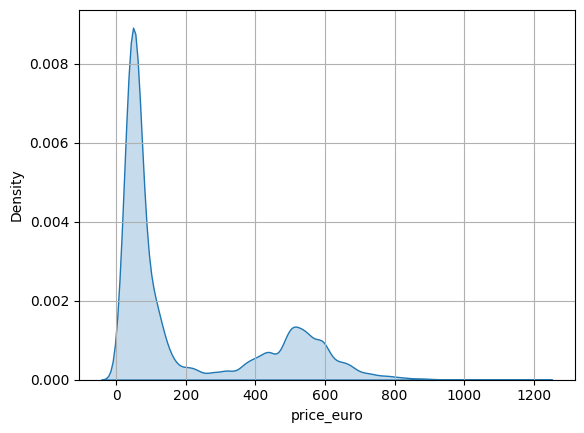

In [87]:
sns.kdeplot(data=df, x="price_euro",fill=True)
plt.grid()

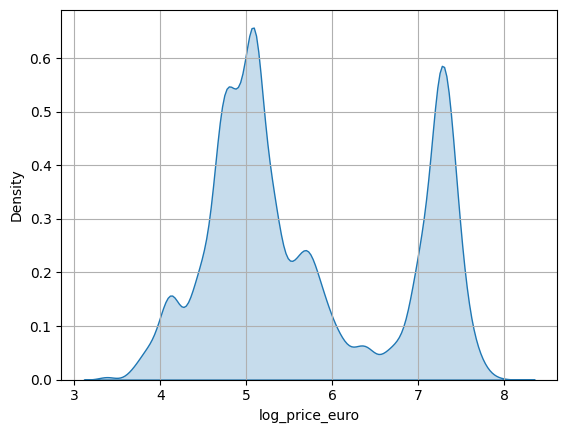

In [88]:
sns.kdeplot(data=df, x="log_price_euro",fill=True)
plt.grid()

**La distribution est bimodale (deux groupes) :**

On voit clairement deux pics :

- un groupe autour de log ~ 5 → ≈ exp(5) ≈ 148 €
- un groupe autour de log ~ 7.2 → ≈ exp(7.2) ≈ 1 340 €

Ça veut dire que tes prix proviennent de deux types economy et business.

<Axes: xlabel='price_euro'>

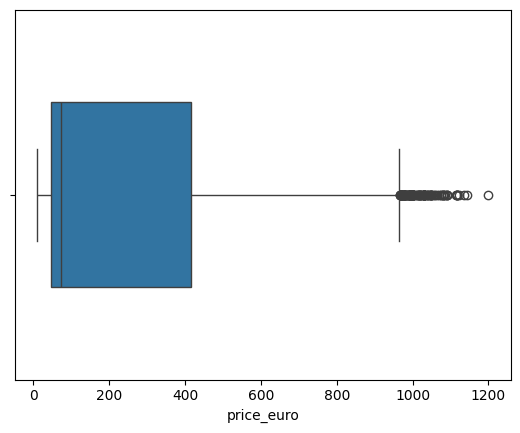

In [89]:
sns.boxplot(x=df["price_euro"],width=.5)

<Axes: xlabel='log_price_euro'>

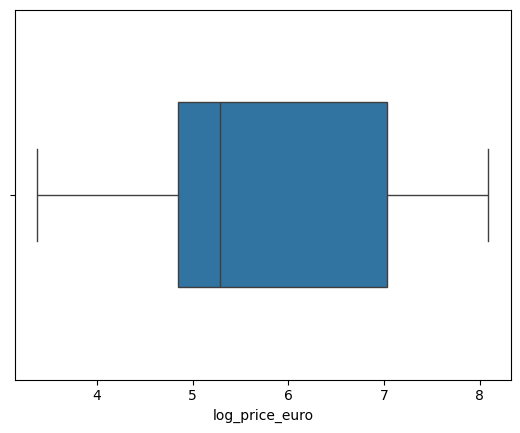

In [90]:
sns.boxplot(x=df["log_price_euro"],width=.5)

| Modèle                        | Log(Y) recommandé ? | Pourquoi                               |
|------------------------------|----------------------|-----------------------------------------|
| Random Forest                |  Non               | Gère les distributions asymétriques     |
| XGBoost / LightGBM / Catboost|  Non               | Optimise sur l’échelle brute            |
| Régression linéaire          |  Oui               | Normalité + variance stable             |
| Ridge / Lasso / ElasticNet   |  Oui               | Même raison                              |
| Réseaux neuronaux            |  Parfois           | Dépend du problème                       |


In [91]:
df.columns

Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price', 'price_euro', 'log_price_euro'],
      dtype='object')

**Variable duration:**

<Axes: xlabel='duration'>

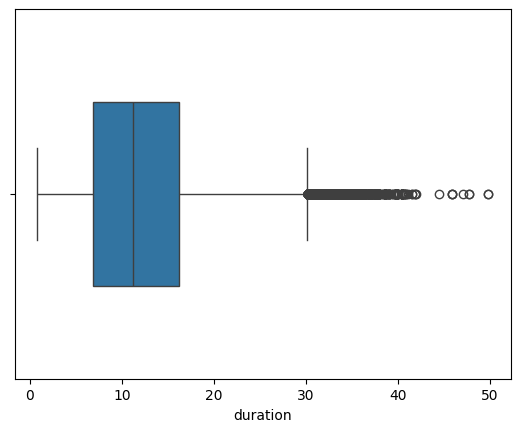

In [92]:
sns.boxplot(x=df["duration"],width=.5)

je sais pas si je mets en Log, à voir dans l'analyse multivarié

**Variable day left:**

<Axes: xlabel='days_left'>

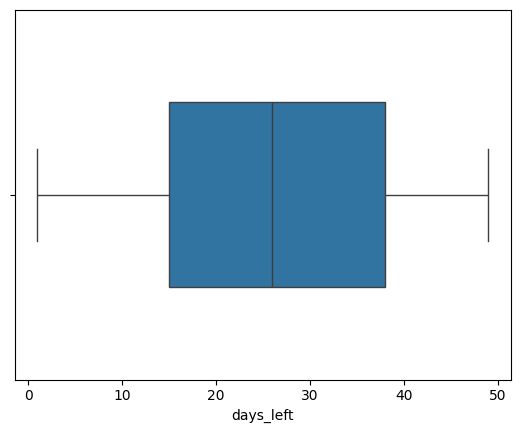

In [93]:
sns.boxplot(x=df["days_left"],width=.5)

### Variables catégorielles : 

In [94]:
for value in df.select_dtypes(include=['object']).columns : 
    print(f"======{value}======")
    print(df[f"{value}"].value_counts())

======airline======
airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64
======flight======
flight
UK-706     3235
UK-772     2741
UK-720     2650
UK-836     2542
UK-822     2468
           ... 
6E-2914       1
G8-107        1
SG-9974       1
6E-865        1
SG-8339       1
Name: count, Length: 1561, dtype: int64
======source_city======
source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64
======departure_time======
departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64
======stops======
stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64
======arrival_time======
arrival_time
Night            91538
Evening          78323
Mo

In [95]:
for col in df.select_dtypes(include=['object']).columns:
    print(f"====== {col} ======")
    print((df[col].value_counts(normalize=True) * 100).round(2).astype(str) + "%")
    print()


====== airline ======
airline
Vistara       42.6%
Air_India    26.95%
Indigo       14.37%
GO_FIRST      7.72%
AirAsia       5.36%
SpiceJet       3.0%
Name: proportion, dtype: object

====== flight ======
flight
UK-706     1.08%
UK-772     0.91%
UK-720     0.88%
UK-836     0.85%
UK-822     0.82%
           ...  
6E-2914     0.0%
G8-107      0.0%
SG-9974     0.0%
6E-865      0.0%
SG-8339     0.0%
Name: proportion, Length: 1561, dtype: object

====== source_city ======
source_city
Delhi        20.44%
Mumbai       20.29%
Bangalore    17.34%
Kolkata      15.44%
Hyderabad     13.6%
Chennai      12.89%
Name: proportion, dtype: object

====== departure_time ======
departure_time
Morning           23.7%
Early_Morning    22.25%
Evening          21.69%
Night             16.0%
Afternoon        15.92%
Late_Night        0.44%
Name: proportion, dtype: object

====== stops ======
stops
one            83.58%
zero            12.0%
two_or_more     4.43%
Name: proportion, dtype: object

====== arrival_tim

- variable airline : la distribution montre une dominance de Vistara et Air_India, mais les autres compagnies restent suffisamment représentées pour fournir un signal utile. La variable est informative et doit être conservée.

- variable source_city : proportions proches entre les différentes villes, ce qui rend la variable bien équilibrée. Elle est pertinente pour expliquer les différences de prix et doit être conservée.

- variable departure_time : la majorité des catégories sont bien représentées, avec seulement Late_Night peu présent. La répartition est suffisante pour conserver la variable telle quelle.

- variable stops : forte domination des vols avec une escale, mais cette structure reflète les données réelles et influence directement le prix. La variable est essentielle et doit être conservée.

- variable arrival_time : répartition correcte entre les moments de la journée, permettant de capturer des effets temporels sur les prix. La variable est utile et doit être conservée.

- variable destination_city : distribution équilibrée entre les villes, similaire à source_city, ce qui en fait une variable informative à conserver.

- variable class : déséquilibre modéré entre Economy et Business, mais les deux catégories sont largement assez représentées pour être exploitées. La variable est pertinente et doit être conservée.


## Analayse Multivarié : 

**Variables : Price et class**

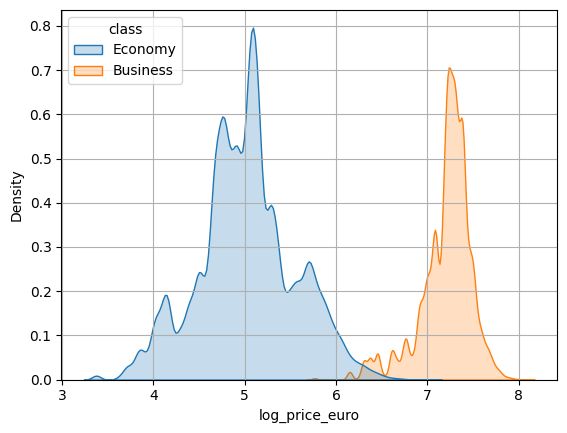

In [115]:
sns.kdeplot(data=df, x="log_price_euro", hue="class",fill=True)
plt.grid()

- les distributions des prix en log montrent une séparation nette entre Economy et Business : la densité Business se situe entièrement à droite de la densité Economy, ce qui indique que les billets Business sont systématiquement plus chers dans ce dataset.


- le chevauchement entre les deux courbes est presque nul, ce qui signifie qu’il n’existe pratiquement aucun cas où un billet Business est moins cher qu’un billet Economy dans les données observées.

- la variable class représente donc un facteur tarifaire fort et cohérent : la classe Business correspond bien à un niveau de prix plus élevé que l’Economy, et elle doit être conservée comme un prédicteur important pour le modèle.


**Variables : Price et Duration**

<Axes: xlabel='duration', ylabel='price_euro'>

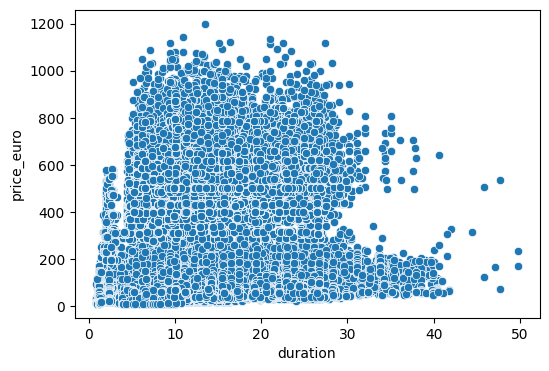

In [99]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["duration"], y=df["price_euro"])

Les points très à droite (durée longue) sont dans la même fourchette de prix que les autres.
Ils ne cassent pas la forme du nuage.
Ils ne créent pas une tendance bizarre.
Donc :
- Les valeurs extrêmes suivent la même logique que le reste des données.
- Elles ne “déforment” pas le modèle.
Conclusion : on la garde comme ça

**Price et DaysLefts :**

<Axes: xlabel='days_left', ylabel='price_euro'>

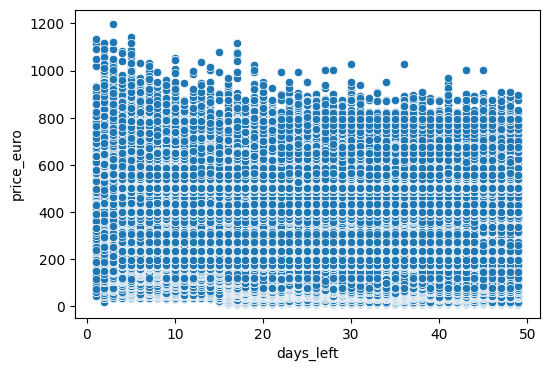

In [104]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["days_left"], y=df["price_euro"])

- la relation globale entre days_left et le prix est faible, mais cela ne signifie pas que la variable est inutile : l’effet de l’anticipation peut varier fortement selon les compagnies.

- certaines compagnies low-cost ajustent leurs prix de manière agressive en fonction de la date d’achat, créant un effet days_left marqué, tandis que d’autres ont une tarification plus stable, ce qui dilue la tendance dans le graphique global.

- en séparant les compagnies, on peut faire apparaître des patterns qui disparaissent lorsqu’on mélange toutes les observations : certaines compagnies augmentent fortement les prix en dernière minute, d’autres au contraire offrent des promotions tardives.

- la variable days_left peut donc contenir un signal utile, mais il est conditionné par airline ; l’interaction entre les deux variables peut être importante pour améliorer les performances du modèle.

- cette interaction sera naturellement capturée par des modèles basés sur des arbres (RandomForest, XGBoost, CatBoost), qui peuvent apprendre des relations du type “si airline = X et days_left < 5 alors prix élevé”.


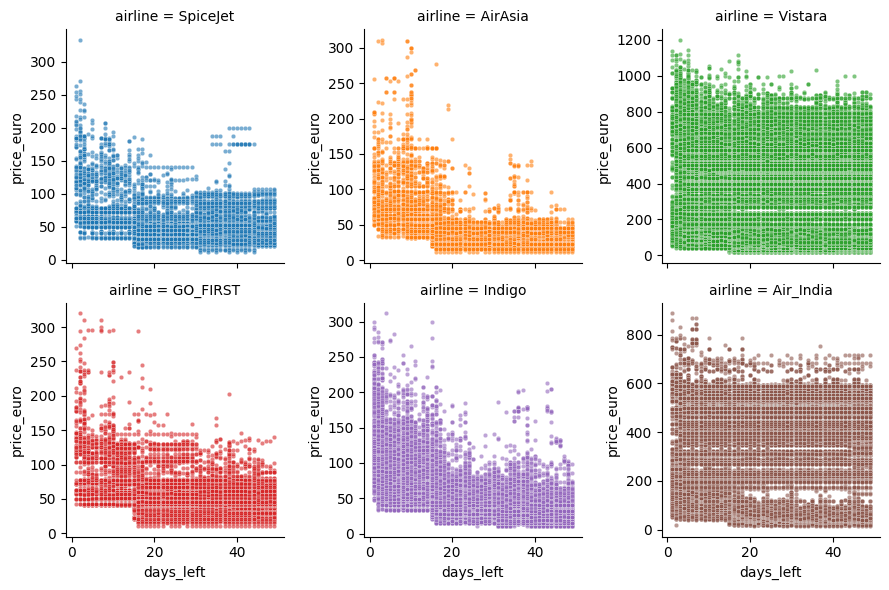

In [112]:
unique_airlines = df["airline"].unique()
palette = dict(zip(unique_airlines, sns.color_palette("tab10", len(unique_airlines))))

g = sns.FacetGrid(
    df,
    col="airline",
    col_wrap=3,
    height=3,
    sharey=False
)

def colored_scatter(data, color, **kwargs):
    airline = data["airline"].iloc[0]
    sns.scatterplot(
        data=data,
        x="days_left",
        y="price_euro",
        s=10,
        alpha=0.6,
        color=palette[airline]
    )

g.map_dataframe(colored_scatter)

- les compagnies low-cost (SpiceJet, AirAsia, GO_FIRST, Indigo) montrent une tendance nette où les prix les plus élevés apparaissent principalement lorsque days_left est faible, tandis que les prix deviennent plus homogènes ou plus bas lorsqu’on s’éloigne de la date du vol.

- Vistara présente une structure différente : les prix restent élevés même lorsque days_left augmente, ce qui indique une politique tarifaire moins sensible à l’anticipation et davantage liée au type de vol (long-courrier, segments premium).

- Air_India affiche un comportement intermédiaire : certains prix élevés se concentrent en dernière minute, mais la dispersion reste élevée quel que soit l’horizon d’achat, suggérant à la fois un effet days_left partiel et une forte influence d’autres facteurs comme la distance ou les escales.

- l’effet de days_left n’est donc pas uniforme : il dépend fortement de la compagnie, ce qui explique pourquoi le scatter global semblait plat lorsque toutes les observations étaient mélangées.

- cette hétérogénéité indique que l’interaction entre airline et days_left est informative et qu’un modèle basé sur des arbres pourra naturellement apprendre des règles conditionnelles propres à chaque compagnie.


**Variables : Price et city de depart**

C:\Users\jbche\AppData\Local\Temp\ipykernel_13020\3965443718.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="source_city", y="log_price_euro",palette="Set2")


<Axes: xlabel='source_city', ylabel='log_price_euro'>

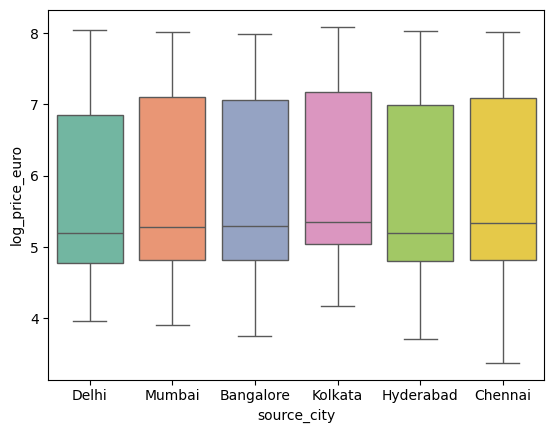

In [118]:
sns.boxplot(data=df, x="source_city", y="log_price_euro",palette="Set2")

- la distribution des prix en log est globalement similaire entre les différentes villes de départ, avec des médianes proches et des étendues comparables, ce qui indique que le lieu de départ n’entraîne pas de différences tarifaires majeures dans ce dataset.

**Variables : Price et detination_city**

C:\Users\jbche\AppData\Local\Temp\ipykernel_13020\3313532387.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="destination_city", y="log_price_euro",palette="Set2")


<Axes: xlabel='destination_city', ylabel='log_price_euro'>

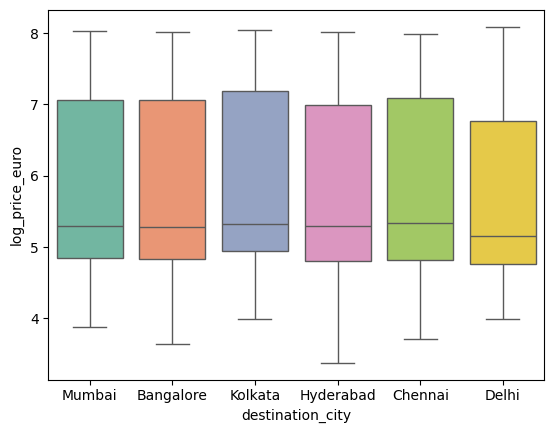

In [123]:
sns.boxplot(data=df, x="destination_city", y="log_price_euro",palette="Set2")

- la distribution des prix en log est globalement similaire entre les différentes villes d'arrivées, avec des médianes proches et des étendues comparables, ce qui indique que le lieu de départ n’entraîne pas de différences tarifaires majeures dans ce dataset.

**Variables :(departs x arrivée) x prix**

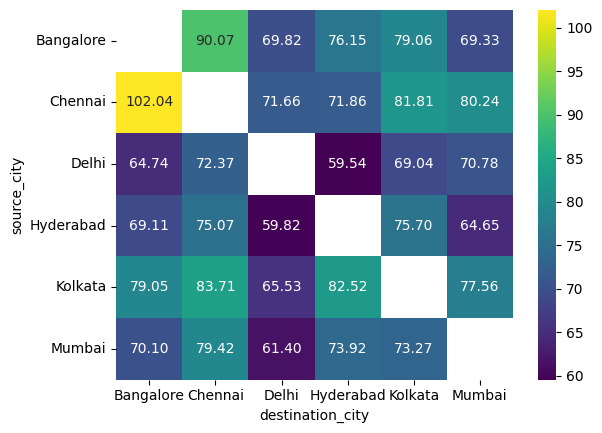

In [128]:
pivot = df.pivot_table(
    index="source_city",
    columns="destination_city",
    values="price_euro",
    aggfunc="median"
)

sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis")
plt.show()


- les routes les plus chères apparaissent clairement entre Chennai et Bangalore, Chennai étant associé aux valeurs les plus élevées de la matrice, ce qui indique que les vols impliquant Chennai ont des tarifs systématiquement supérieurs dans ce dataset.

- les routes les moins chères concernent principalement Delhi et Hyderabad, qui présentent des prix médians nettement inférieurs aux autres combinaisons de villes, reflétant des trajets plus courts ou des corridors fortement desservis.

- les routes depuis Kolkata affichent des prix intermédiaires mais relativement stables selon la destination, ce qui suggère une structure tarifaire moins sensible au choix de la ville d’arrivée.

- Mumbai et Bangalore présentent des tarifs modérés et assez homogènes entre destinations, ce qui indique que ces hubs génèrent des prix moins affectés par la combinaison spécifique source–destination.

- l’ensemble de la heatmap montre que certaines routes se détachent nettement (Chennai–Bangalore, Chennai–Hyderabad) tandis que d’autres restent étonnamment économiques (Delhi–Hyderabad, Delhi–Mumbai), confirmant que la paire source–destination est un facteur pertinent pour expliquer la variation des prix.


**On en creee une variable ducoup :**

- la variable route existe aussi dans le test, donc on peut l'encoder en utilisant les moyennes apprises sur le train.

- on ne calcule jamais la moyenne du prix avec les données du test, ce qui évite toute fuite d’information.

- chaque valeur route du test est remplacée par la moyenne de la même route calculée sur le train.

- si une route n’est pas présente dans le train, on la remplace par la moyenne globale du train, ce qui garantit un encodage complet et propre.


- pour la régression linéaire, la meilleure méthode est le target encoding car il évite l’ordre arbitraire de l’ordinal et réduit le nombre de colonnes par rapport au one-hot.

- pour les modèles d’arbres comme RandomForest, XGBoost ou LightGBM, l’ordinal encoding est suffisant car ces modèles ne tiennent pas compte de l’ordre numérique et utilisent la valeur comme un identifiant.

- pour CatBoost, aucune transformation n’est nécessaire car le modèle gère automatiquement les variables catégorielles de manière optimale.

- ces choix assurent un encodage simple, efficace et adapté à chaque type de modèle sans explosion du nombre de colonnes ni fuite d’information.


In [137]:
enc = OrdinalEncoder()
df["route_ord"] = enc.fit_transform(df[["route"]])
route_mean = df.groupby("route")["log_price_euro"].transform("mean")
df["route_te"] = route_mean

In [129]:
df["route"] = df["source_city"] + "_" + df["destination_city"]

In [106]:
df.corr(numeric_only=True)

,Unnamed: 0,duration,days_left,price,price_euro,log_price_euro
Unnamed: 0,1.000000,0.159007,0.014638,0.761177,0.761177,0.736447
duration,0.159007,1.000000,-0.039157,0.204222,0.204222,0.264296
days_left,0.014638,-0.039157,1.000000,-0.091949,-0.091949,-0.193535
price,0.761177,0.204222,-0.091949,1.000000,1.000000,0.946196
price_euro,0.761177,0.204222,-0.091949,1.000000,1.000000,0.946196
log_price_euro,0.736447,0.264296,-0.193535,0.946196,0.946196,1.000000


**Variables : Price et airlines**

C:\Users\jbche\AppData\Local\Temp\ipykernel_13020\1326249854.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="airline", y="log_price_euro",palette="Set2")


<Axes: xlabel='airline', ylabel='log_price_euro'>

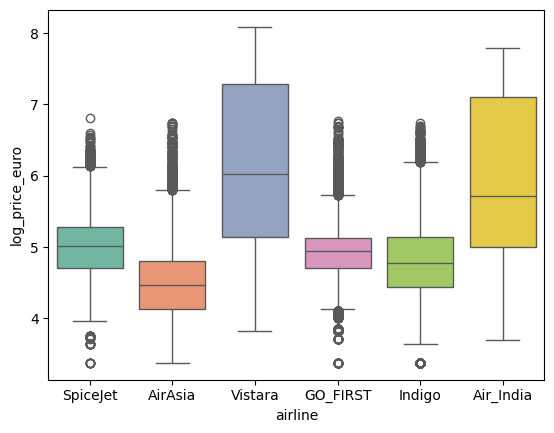

In [138]:
sns.boxplot(data=df, x="airline", y="log_price_euro",palette="Set2")

- le passage au log rend la distribution du prix plus stable et plus lisible sans perdre d’information, ce qui facilite l’interprétation et améliore la compatibilité avec les modèles linéaires.

- la variable airline reste clairement informative après la transformation : les compagnies low-cost conservent des niveaux de prix plus bas et plus homogènes, tandis que Vistara et Air_India montrent des distributions plus élevées et plus dispersées.

- les valeurs extrêmes visibles après la transformation log correspondent à des vols réels et ne constituent pas des erreurs, il n’est donc pas nécessaire de supprimer des observations.



C:\Users\jbche\AppData\Local\Temp\ipykernel_13020\3744670228.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="stops", y="log_price_euro",palette="Set2")


<Axes: xlabel='stops', ylabel='log_price_euro'>

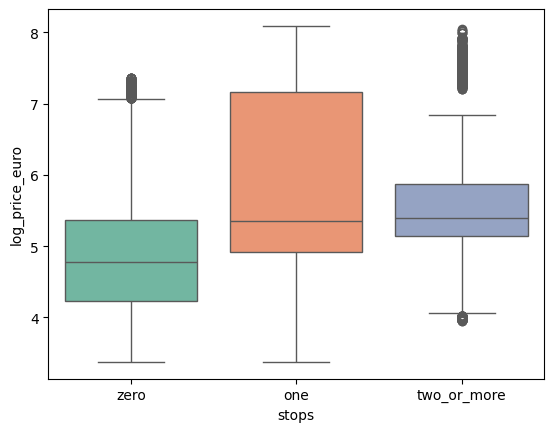

In [139]:
sns.boxplot(data=df, x="stops", y="log_price_euro",palette="Set2")

- la variable stops est liée à la durée totale du trajet : les vols avec une ou plusieurs escales sont généralement associés à des trajets plus longs, ce qui augmente mécaniquement le prix moyen observé dans le dataset.

- les vols sans escale présentent des prix plus bas en log, cohérents avec des trajets plus courts et plus simples, tandis que les vols avec une escale montrent une variabilité plus large liée à la diversité des itinéraires longue distance.

- les vols avec deux escales ou plus restent globalement plus chers que les vols directs, mais leur médiane se situe en au même niveau que  les vols avec une seule escale, probablement en raison de routes spécifiques, compagnies particulières ou comportements tarifaires propres à ces cas.

- les différences entre catégories sont donc cohérentes avec la structure du marché aérien et reflètent principalement l’effet combiné du nombre d’escales, de la distance totale et des durées de vol.

- la variable stops apporte une information significative sur le prix et doit être conservée telle quelle, sans suppression de valeurs ni retrait de catégories.


# Preprocessing

In [ ]:
df.drop("Unnamed: 0",
        axis=1,
        inplace = True)

**On va faire du binaire pour les variables catégorielles a 2 modalités**

In [ ]:
df["class"] = df["class"].replace({"Business" : 1,
                                   "Economy" : 0})

C:\Users\jbche\AppData\Local\Temp\ipykernel_13020\4171413487.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["class"] = df["class"].replace({"Business" : 1,


**On va faire du Ordinal encoding pour les variables caétgorielles qui ont une hierachie**

In [ ]:
df["stops"] = df["stops"].replace({
    "zero": 0,
    "one": 1,
    "two_or_more": 2
})

C:\Users\jbche\AppData\Local\Temp\ipykernel_13020\2358550755.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["stops"] = df["stops"].replace({


**On va faire du One Hot encoding pour les variables caétgorielles sans hiearchie**

In [ ]:
def one_hot_encoding(colonnes: list[str], dataframe: pd.DataFrame) -> pd.DataFrame:
    df = dataframe.copy()
    for col in colonnes:
        dummies = pd.get_dummies(df[col], prefix=col,dtype=int)
        df = df.drop(columns=[col])       
        df = df.join(dummies)  
    return df

df = one_hot_encoding(["airline","source_city","arrival_time","destination_city","departure_time"],df)


In [ ]:
df.head()

,flight,stops,class,duration,days_left,price,price_euro,log_price_euro,airline_AirAsia,airline_Air_India,...,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,departure_time_Afternoon,departure_time_Early_Morning,departure_time_Evening,departure_time_Late_Night,departure_time_Morning,departure_time_Night
0,SG-8709,0,0,2.17,1,5953,58.021442,5.060813,0,0,...,0,0,0,1,0,0,1,0,0,0
1,SG-8157,0,0,2.33,1,5953,58.021442,5.060813,0,0,...,0,0,0,1,0,1,0,0,0,0
2,I5-764,0,0,2.17,1,5956,58.050682,5.061316,1,0,...,0,0,0,1,0,1,0,0,0,0
3,UK-995,0,0,2.25,1,5955,58.040936,5.061149,0,0,...,0,0,0,1,0,0,0,0,1,0
4,UK-963,0,0,2.33,1,5955,58.040936,5.061149,0,0,...,0,0,0,1,0,0,0,0,1,0


# Modélisation

In [ ]:
X = df.drop("price",axis=1)
Y = df["price"]